# 37. ML Foundations — the Folk Wisdom

**Tier:** Classic ML
**Estimated time:** 40 minutes
**Prerequisites:** None — runs standalone, fully offline
**Priority:** 🔴 Crucial — generalization, overfitting, and the bias/variance tradeoff are the vocabulary every later eval notebook (24, 25, 27b) assumes you already have. *If skipped, revisit when:* "overfitting" starts getting used loosely, or before notebook 25.
**Source material:** Pedro Domingos, ["A Few Useful Things to Know About Machine Learning"](https://homes.cs.washington.edu/~pedrod/papers/cacm12.pdf), Communications of the ACM, 2012.

## What You'll Learn
- Learning = **Representation + Evaluation + Optimization** — the three levers every model-building decision pulls
- Why **generalization**, not training-set fit, is the actual goal — and how to measure the gap
- The **bias–variance tradeoff**, decomposed numerically rather than just described
- The **curse of dimensionality** — why intuitions from 2D/3D quietly break as feature count grows
- Why **more data usually beats a cleverer algorithm**, and why **averaging many overfit models beats any one of them** (a preview of notebook 39)

## Why This Matters
Every model you'll build in this repo — a 14M-parameter transformer in P1, a fine-tuned LoRA adapter in notebook 08, a random forest in notebook 39 — fails or succeeds along exactly these axes. A model that memorizes its training set is not "smart," it's overfit; a model that can't fit even its training set is underfit. Knowing which one you're looking at, and why, is the single most transferable skill in machine learning.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(37)
print("Setup complete — numpy, matplotlib, seeded RNG.")

Setup complete — numpy, matplotlib, seeded RNG.


## Learning = Representation + Evaluation + Optimization

Domingos' central framing: every learning algorithm, however fancy, is three independent choices.

- **Representation** — the space of models you're willing to search. A straight line, a
  degree-15 polynomial, a decision tree, a transformer — each defines a different *hypothesis
  space*. Pick a representation too narrow and the true pattern isn't even expressible; pick
  one too wide and you can fit anything, including noise.
- **Evaluation** — the score that tells candidates apart (a loss function, accuracy, log-likelihood).
  This is *what "better" means* for your problem.
- **Optimization** — the search procedure that finds a good model within the representation,
  as judged by the evaluation function (grid search, gradient descent, greedy tree-splitting).

Mixing these up causes real confusion: "my model is bad" might mean the representation is too
weak (no line can separate these classes), the evaluation is wrong (accuracy on imbalanced
data hides the failure), or the optimizer got stuck (gradient descent found a bad local
minimum). The rest of this notebook works through the representation axis — model
complexity — because it's the one every later notebook leans on.

## Generalization is the goal, not fitting the data

A model that reproduces its training set perfectly has not learned anything useful yet — it
may have just memorized. The only test that matters is performance on data the model has
never seen. We'll make this concrete: fit polynomials of increasing degree to noisy data drawn
from a known function, and watch **training error keep falling while test error turns back up**.

In [2]:
def true_function(x):
    return np.sin(x) * 2.0

# One shared dataset for the whole notebook: noisy samples from a known sine curve.
N_TRAIN, N_TEST = 30, 200
X_train = rng.uniform(0, 2 * np.pi, N_TRAIN)
y_train = true_function(X_train) + rng.normal(0, 0.5, N_TRAIN)
X_test = rng.uniform(0, 2 * np.pi, N_TEST)
y_test = true_function(X_test) + rng.normal(0, 0.5, N_TEST)

def fit_poly(x, y, degree):
    # Polynomial.fit auto-scales x into [-1, 1] internally, which keeps high-degree
    # fits numerically well-conditioned (raw np.polyfit on x in [0, 2*pi] blows up
    # past degree ~10 — x**15 terms make the Vandermonde matrix nearly singular).
    return np.polynomial.Polynomial.fit(x, y, degree)

def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

degrees = [1, 2, 3, 5, 9, 15]
train_errs, test_errs = [], []
for d in degrees:
    model = fit_poly(X_train, y_train, d)
    train_errs.append(mse(y_train, model(X_train)))
    test_errs.append(mse(y_test, model(X_test)))

for d, tr, te in zip(degrees, train_errs, test_errs):
    print(f"degree={d:>2}  train MSE={tr:6.3f}  test MSE={te:6.3f}")

degree= 1  train MSE= 1.674  test MSE= 1.151
degree= 2  train MSE= 1.664  test MSE= 1.183
degree= 3  train MSE= 0.160  test MSE= 0.303
degree= 5  train MSE= 0.157  test MSE= 0.297
degree= 9  train MSE= 0.147  test MSE= 0.277
degree=15  train MSE= 0.119  test MSE= 0.726


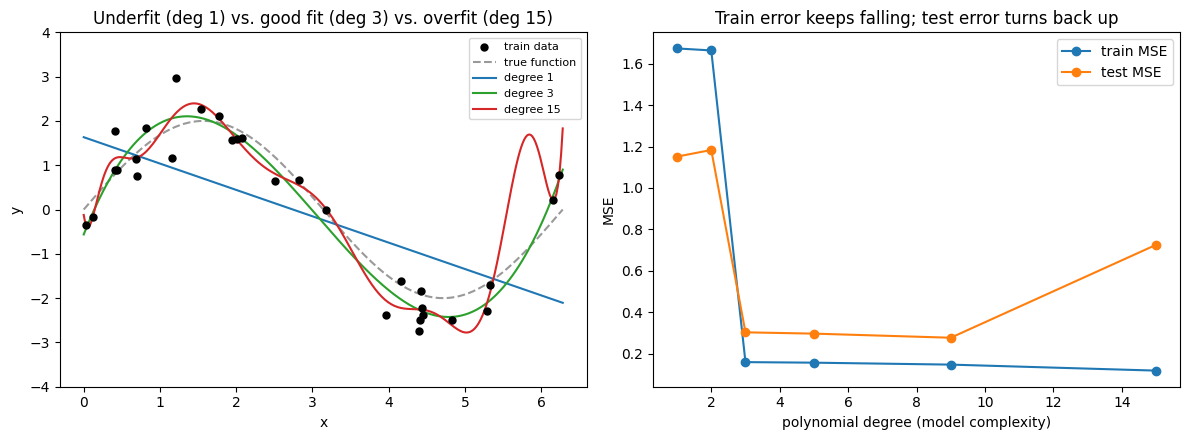

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

xs_smooth = np.linspace(0, 2 * np.pi, 300)
ax = axes[0]
ax.scatter(X_train, y_train, color="black", s=25, zorder=5, label="train data")
ax.plot(xs_smooth, true_function(xs_smooth), "k--", alpha=0.4, label="true function")
for d, color in zip([1, 3, 15], ["tab:blue", "tab:green", "tab:red"]):
    model = fit_poly(X_train, y_train, d)
    ax.plot(xs_smooth, model(xs_smooth), color=color, label=f"degree {d}")
ax.set_ylim(-4, 4)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Underfit (deg 1) vs. good fit (deg 3) vs. overfit (deg 15)")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(degrees, train_errs, marker="o", label="train MSE")
ax.plot(degrees, test_errs, marker="o", label="test MSE")
ax.set_xlabel("polynomial degree (model complexity)")
ax.set_ylabel("MSE")
ax.set_title("Train error keeps falling; test error turns back up")
ax.legend()
plt.tight_layout()
plt.show()

*Left: the degree-15 curve snakes through every training point but wanders wildly between
them — it fit the noise, not the sine wave. Right: this is the single most important chart in
machine learning. Training error is monotonically non-increasing with complexity (a more
flexible model can only fit the training set better or equal); test error is U-shaped. The
gap between the two curves at high degree **is** overfitting, made numeric.*

## Bias and variance, decomposed — not just described

"Underfitting" and "overfitting" are usually explained with a picture like the one above. But
there's a precise decomposition behind it. If you retrained the *same* model on many different
random training sets and looked at its predictions on one fixed test point:

- **Bias** — how far the *average* prediction (across those retrainings) is from the truth.
  High bias means the model's representation is too rigid to capture the pattern at all,
  regardless of the specific training data it saw.
- **Variance** — how much predictions *swing* across those different retrainings. High
  variance means the model is so flexible it fits whatever noise happened to be in this
  particular training set.

Total expected error decomposes as `bias² + variance + irreducible noise`. A degree-1
polynomial can't bend to match a sine wave no matter what data it sees — that's bias. A
degree-9 polynomial bends to match whatever 30 noisy points it happens to get — that's
variance. We can measure both directly by refitting on many freshly drawn training sets.

In [4]:
def bias_variance_decompose(degree, n_resamples=300):
    grid = np.linspace(0.5, 2 * np.pi - 0.5, 60)  # avoid edge effects
    truth = true_function(grid)
    preds = np.zeros((n_resamples, len(grid)))
    for i in range(n_resamples):
        # Fresh draw from the same distribution each time (not a bootstrap of the
        # fixed X_train) — bootstrapping a small sample creates duplicate x-values,
        # which makes a degree-15 fit's Vandermonde matrix nearly singular.
        x = rng.uniform(0, 2 * np.pi, N_TRAIN)
        y = true_function(x) + rng.normal(0, 0.5, N_TRAIN)
        model = fit_poly(x, y, degree)
        preds[i] = model(grid)
    mean_pred = preds.mean(axis=0)
    bias_sq = np.mean((mean_pred - truth) ** 2)
    variance = np.mean(preds.var(axis=0))
    return bias_sq, variance, preds, grid, truth

results = {d: bias_variance_decompose(d) for d in [1, 9]}
for d, (b2, v, *_ ) in results.items():
    print(f"degree={d:>2}  bias^2={b2:.3f}  variance={v:.3f}  bias^2+variance={b2+v:.3f}")

degree= 1  bias^2=0.572  variance=0.074  bias^2+variance=0.646
degree= 9  bias^2=0.005  variance=1.260  bias^2+variance=1.265


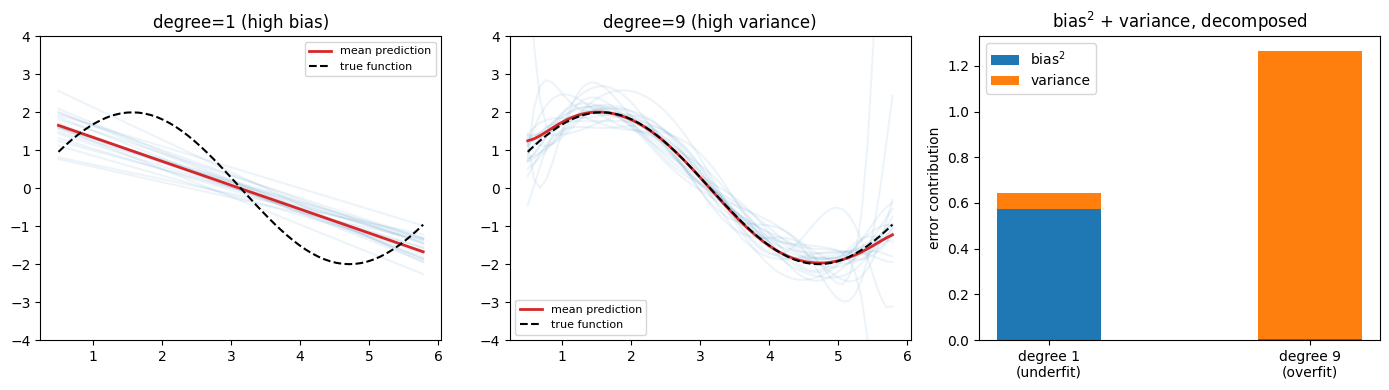

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, d in zip(axes[:2], [1, 9]):
    _, _, preds, grid, truth = results[d]
    for i in range(0, 300, 15):  # a sample of the resampled fits
        ax.plot(grid, preds[i], color="tab:blue", alpha=0.08)
    ax.plot(grid, preds.mean(axis=0), color="tab:red", lw=2, label="mean prediction")
    ax.plot(grid, truth, "k--", label="true function")
    ax.set_ylim(-4, 4)
    ax.set_title(f"degree={d} ({'high bias' if d == 1 else 'high variance'})")
    ax.legend(fontsize=8)

ax = axes[2]
labels = ["degree 1\n(underfit)", "degree 9\n(overfit)"]
bias_sqs = [results[1][0], results[9][0]]
variances = [results[1][1], results[9][1]]
x = np.arange(2)
ax.bar(x, bias_sqs, width=0.4, label="bias$^2$")
ax.bar(x, variances, width=0.4, bottom=bias_sqs, label="variance")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("error contribution")
ax.set_title("bias$^2$ + variance, decomposed")
ax.legend()
plt.tight_layout()
plt.show()

*Left two panels: each faint blue line is one refit on a different freshly drawn training set. The
degree-1 fits barely move (low variance) but their average (red) misses the sine's curvature
everywhere (high bias). The degree-9 fits swing wildly point to point (high variance) even
though their average happens to track the truth reasonably well (lower bias). Right: this is
the tradeoff as two stacked numbers — the "good" model from the earlier plot (degree 3) sits
between these two extremes on both axes.*

## The curse of dimensionality

Low-dimensional intuition breaks down as the number of features grows. A concrete example:
in a unit hypercube, pick points at random and measure the distance from the origin to the
*nearest* point and to the *farthest* point. In 2D these distances are very different — "near"
and "far" mean something. As dimensionality grows, nearly all points end up roughly the same
distance away, and the ratio of nearest-to-farthest distance creeps toward 1. This is why
k-nearest-neighbors and raw distance-based similarity degrade in high dimensions — and part
of why embeddings (notebook 03) are learned *representations*, not raw high-dimensional
feature vectors, for exactly this reason.

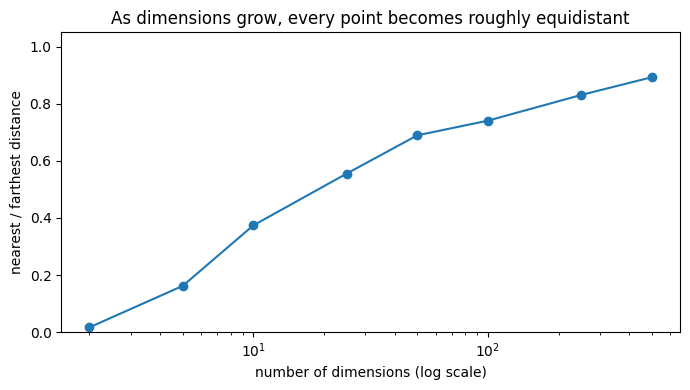

At 2 dims, ratio=0.02. At 500 dims, ratio=0.89.


In [6]:
def nearest_farthest_ratio(n_dims, n_points=500):
    points = rng.uniform(0, 1, (n_points, n_dims))
    dists = np.linalg.norm(points, axis=1)
    return dists.min() / dists.max()

dim_range = [2, 5, 10, 25, 50, 100, 250, 500]
ratios = [nearest_farthest_ratio(d) for d in dim_range]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(dim_range, ratios, marker="o")
ax.set_xscale("log")
ax.set_xlabel("number of dimensions (log scale)")
ax.set_ylabel("nearest / farthest distance")
ax.set_title("As dimensions grow, every point becomes roughly equidistant")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()
print(f"At {dim_range[0]} dims, ratio={ratios[0]:.2f}. At {dim_range[-1]} dims, ratio={ratios[-1]:.2f}.")

*In 2D, the nearest point can be many times closer than the farthest — "nearest neighbor"
is meaningful. By a few hundred dimensions, the ratio approaches 1: everything is
approximately equidistant, and distance-based reasoning loses its discriminative power. This
is exactly why raw pixel or one-hot feature spaces need dimensionality reduction or learned
embeddings before nearest-neighbor methods are useful on them.*

## More data usually beats a cleverer algorithm

Domingos' most quoted line: given a choice between more data and a fancier algorithm, take
the data. Why? More training data mostly attacks **variance**, not bias. A model whose
representation is fundamentally too rigid (high bias) won't improve much no matter how much
data you throw at it — but a flexible model's wild, data-hungry fluctuations calm down as `n`
grows. We can see both effects on the same plot by tracking test error as training-set size
increases, for a low-complexity and a high-complexity model side by side.

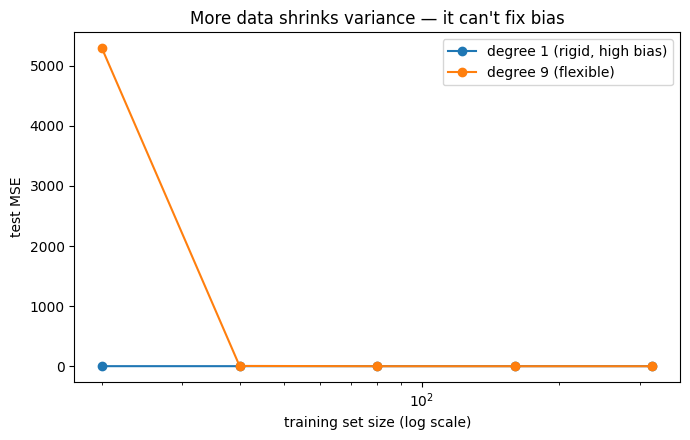

degree 1: 1.22 -> 1.10 (barely moves)
degree 9: 5291.77 -> 0.27 (falls sharply, then flattens)


In [7]:
def learning_curve(degree, sizes, n_trials=40):
    errs = []
    for n in sizes:
        trial_errs = []
        for _ in range(n_trials):
            x = rng.uniform(0, 2 * np.pi, n)
            y = true_function(x) + rng.normal(0, 0.5, n)
            model = fit_poly(x, y, min(degree, n - 1))
            trial_errs.append(mse(y_test, model(X_test)))
        errs.append(np.mean(trial_errs))
    return errs

sizes = [20, 40, 80, 160, 320]  # below n=20, degree-9 (10 free params) nearly interpolates and
                                # the fit becomes numerically chaotic — the effect is real, but
                                # starting at 20 keeps the demo readable instead of astronomical
simple_errs = learning_curve(degree=1, sizes=sizes)   # rigid: high bias
flexible_errs = learning_curve(degree=9, sizes=sizes)  # flexible: high variance at low n

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sizes, simple_errs, marker="o", label="degree 1 (rigid, high bias)")
ax.plot(sizes, flexible_errs, marker="o", label="degree 9 (flexible)")
ax.set_xscale("log")
ax.set_xlabel("training set size (log scale)")
ax.set_ylabel("test MSE")
ax.set_title("More data shrinks variance — it can't fix bias")
ax.legend()
plt.tight_layout()
plt.show()
print(f"degree 1: {simple_errs[0]:.2f} -> {simple_errs[-1]:.2f} (barely moves)")
print(f"degree 9: {flexible_errs[0]:.2f} -> {flexible_errs[-1]:.2f} (falls sharply, then flattens)")

*The rigid degree-1 model's error barely improves with more data — its bias is a ceiling
data can't break through. The degree-9 model starts far worse with only 20 points (barely
enough to pin down 10 coefficients — pure variance) but falls sharply and, given
enough data, ends up beating the rigid model. The lesson isn't "always use the most flexible
model" — it's that a representation with enough capacity, fed enough data, usually wins over
a cleverer but more constrained one. (Notebook 07's scaling laws are this same curve at a
very different scale — more pretraining data and a big-enough architecture, not algorithmic
cleverness, is most of what has driven LLM progress.)*

## Learn many models: averaging cures variance for free

One more Domingos maxim: don't just pick the single best model — combine several. If a
high-variance model's error comes from randomly overfitting to whatever noise was in *its*
training sample, then models trained on *different* samples make *different* mistakes — and
averaging their predictions cancels much of that noise out, without adding any bias. This is
the entire idea behind bagging and random forests (notebook 39); here it is in miniature using
the same overfit degree-9 polynomials from before.

In [8]:
_, _, overfit_preds, grid, truth = results[9]

single_model_errs = [mse(truth, overfit_preds[i]) for i in range(len(overfit_preds))]
ensemble_pred = overfit_preds.mean(axis=0)
ensemble_err = mse(truth, ensemble_pred)

print(f"single overfit model — mean test MSE across resamples: {np.mean(single_model_errs):.3f}")
print(f"average of ALL {len(overfit_preds)} overfit models — test MSE: {ensemble_err:.3f}")
print(f"ensembling cut error by {(1 - ensemble_err / np.mean(single_model_errs)) * 100:.0f}% — for free, with the exact same models")

single overfit model — mean test MSE across resamples: 1.265
average of ALL 300 overfit models — test MSE: 0.005
ensembling cut error by 100% — for free, with the exact same models


No single degree-9 model here is trustworthy — each overfits its own sample. But averaging
many of them (each wrong in a *different*, noise-driven way) recovers most of the true sine
curve, because the noise cancels while the shared signal doesn't. This is exactly what
notebook 39's random forest does with decision trees instead of polynomials.

## Exercises

In [9]:
# Exercise 1 (Warm-up): more noise, same story?
# Task: Regenerate X_train/y_train with noise std=1.5 instead of 0.5 (keep N_TRAIN=30), refit
#       the same `degrees` list, and replot train vs test MSE. Does the "good" degree (the one
#       that minimizes test MSE) shift lower or higher than degree 3? Why?
# Hint: more noise means more of what a flexible model fits IS noise — the picture predicts
#       which direction the sweet spot should move.

# YOUR CODE HERE

In [10]:
# Exercise 2 (Apply): implement k-fold cross-validation from scratch
# Task: Without using sklearn, write k_fold_cv(x, y, degree, k=5) that splits the data into k
#       folds, fits on k-1 folds and evaluates MSE on the held-out fold, and returns the mean
#       MSE across folds. Run it for every degree in `degrees` and confirm the CV-selected best
#       degree agrees with (or is close to) the one the held-out X_test/y_test picked earlier.
# Hint: np.array_split(rng.permutation(len(x)), k) gives you k index arrays to rotate through.

# YOUR CODE HERE

In [11]:
# Exercise 3 (Extend): connect to LLM scaling laws
# Task: Notebook 07 (Pretraining & Scaling) describes how LLM loss falls with more data and
#       more parameters. Using this notebook's `learning_curve()` helper, add a THIRD curve for
#       degree=15 to the "more data" plot. At small n it should be even worse than degree 9
#       (more variance to shrink) but should eventually catch up or overtake it. At what
#       training-set size does that crossover happen, and what does that tell you about
#       "bigger models need more data to pay off" (the same idea Chinchilla-style scaling laws
#       formalize for LLMs)?
# Hint: reuse `learning_curve(degree=15, sizes=sizes)` — just add one more line to the plot.

# YOUR CODE HERE

<details>
<summary>Solutions (click to expand)</summary>

```python
# Exercise 1
y_train_noisy = true_function(X_train) + rng.normal(0, 1.5, N_TRAIN)
train_errs_n, test_errs_n = [], []
for d in degrees:
    model = fit_poly(X_train, y_train_noisy, d)
    train_errs_n.append(mse(y_train_noisy, model(X_train)))
    test_errs_n.append(mse(y_test, model(X_test)))
plt.plot(degrees, train_errs_n, marker="o", label="train MSE (noisy)")
plt.plot(degrees, test_errs_n, marker="o", label="test MSE (noisy)")
plt.xlabel("degree"); plt.legend(); plt.show()
# With more noise, the flexible models have more noise available to fit, so the test-error
# minimum shifts to a LOWER degree than before — the sweet spot moves toward simpler models
# as data gets noisier, because there's less real signal worth chasing with extra flexibility.

# Exercise 2
def k_fold_cv(x, y, degree, k=5):
    idx = rng.permutation(len(x))
    folds = np.array_split(idx, k)
    fold_errs = []
    for i in range(k):
        val_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        model = fit_poly(x[train_idx], y[train_idx], degree)
        fold_errs.append(mse(y[val_idx], model(x[val_idx])))
    return np.mean(fold_errs)

cv_errs = [k_fold_cv(X_train, y_train, d) for d in degrees]
best_cv_degree = degrees[int(np.argmin(cv_errs))]
best_test_degree = degrees[int(np.argmin(test_errs))]
print(f"CV picked degree={best_cv_degree}, held-out test set picked degree={best_test_degree}")
# These usually agree or land adjacent in the `degrees` list — cross-validation approximates
# the held-out test set's judgment without spending any additional labeled data on a test split.

# Exercise 3
degree15_curve = learning_curve(degree=15, sizes=sizes)
plt.plot(sizes, simple_errs, marker="o", label="degree 1")
plt.plot(sizes, flexible_errs, marker="o", label="degree 9")
plt.plot(sizes, degree15_curve, marker="o", label="degree 15")
plt.xscale("log"); plt.xlabel("training set size"); plt.legend(); plt.show()
crossover = next((s for s, e9, e15 in zip(sizes, flexible_errs, degree15_curve) if e15 <= e9), None)
print(f"degree 15 catches up to / overtakes degree 9 around n={crossover}")
# The more flexible (higher-capacity) model needs disproportionately more data before its
# lower achievable bias starts to pay off — exactly the "bigger models need more tokens to be
# worth it" logic behind Chinchilla-style compute-optimal scaling laws in notebook 07.
```
</details>

## Key Takeaways
- **Learning = Representation + Evaluation + Optimization.** When a model underperforms, diagnose which of the three is at fault before reaching for a bigger model.
- **Generalization, not training-set fit, is the goal.** Training error only ever goes down as complexity rises — it tells you nothing about deployment quality on its own.
- **Total error decomposes as bias² + variance + irreducible noise.** Rigid models underfit (high bias, low variance); flexible models overfit (low bias, high variance) — and this notebook measured both numerically, not just described them.
- **The curse of dimensionality is real and measurable**: nearest and farthest points become nearly equidistant as feature count grows, which is why raw high-dimensional similarity breaks down and learned embeddings (notebook 03) matter.
- **More data mostly cures variance, not bias** — and **averaging many high-variance models cures variance for free**, which is exactly what a random forest (notebook 39) does with decision trees.

## What's Next
Notebook 38 covers *how* these models actually get fit — from LeCun's practical backprop tricks to the Adam optimizer that trains everything from a 3-layer net to a 70B-parameter LLM.